In [1]:
import sys
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm # For a nice progress bar
import pandas as pd
import os

# 1. Install/Uninstall dependencies (You can comment these out after the first run)
!{sys.executable} -m pip uninstall -y clip
!{sys.executable} -m pip install git+https://github.com/openai/CLIP.git
!{sys.executable} -m pip install ftfy regex tqdm pandas

import clip
print("CLIP installed at:", clip.__file__)

# 2. Load Model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

#model, preprocess = clip.load("ViT-B/32", device=device)
model, preprocess = clip.load("ViT-L/14@336px", device=device)
model.eval() # Set to evaluation mode (we are not training CLIP itself)

input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print(f"Model parameters: {np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print(f"Input resolution: {input_resolution}")

Found existing installation: clip 1.0
Uninstalling clip-1.0:
  Successfully uninstalled clip-1.0
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-csg1dvu4
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-csg1dvu4
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=0a63708eb813005eb461e1bcda47a00e289ef703ba68b7acf3ac39ce6a285dfc
  Stored in directory: /tmp/pip-ephem-wheel-cache-vx1yfj5w/wheels/da/2b/4c/d6691fa9597aac8bb85d2ac13b112deb897d5b50f5ad9a37e4
Successfully built clip
CLIP installed at: /home/teoaivalis/.conda/envs/artbench_env/lib/python3.10/site-packages/clip/__init__.py
Using device: cuda
Model parameters: 427,944,193
Input resolution: 336


the new one

In [2]:
import pandas as pd
from PIL import Image, ImageFile
import os

# Allow PIL to load slightly corrupted images without crashing
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Load the CSVs
aligned_df = pd.read_csv('aligned_paintings.csv')
mapping_df = pd.read_csv('wikiart_art_pieces.csv')

print(f"Loaded {len(aligned_df)} aligned paintings from Neo4j.")

# 2. Clean the URLs
aligned_df['clean_URL'] = aligned_df['URL'].astype(str).apply(lambda x: x.split('!')[0])
mapping_df['clean_img'] = mapping_df['img'].astype(str).apply(lambda x: x.split('!')[0])

# --- THE FIX: Drop duplicates from the mapping CSV before merging! ---
mapping_df = mapping_df.drop_duplicates(subset=['clean_img'], keep='first')
# ---------------------------------------------------------------------

# 3. Merge to find the local file_name (Left merge preserves exact order!)
merged_df = pd.merge(aligned_df, mapping_df[['clean_img', 'file_name']], 
                     left_on='clean_URL', right_on='clean_img', how='left')

missing_mappings = merged_df['file_name'].isna().sum()

print(f"Total rows to process: {len(merged_df)} (Should perfectly match Neo4j: {len(aligned_df)})")

if missing_mappings > 0:
    print(f"WARNING: {missing_mappings} URLs did not match a local 'file_name'.")
else:
    print("Success: All URLs successfully mapped and de-duplicated!")
    
merged_df.head()

Loaded 47224 aligned paintings from Neo4j.
Total rows to process: 47224 (Should perfectly match Neo4j: 47224)
Success: All URLs successfully mapped and de-duplicated!


,ImageName,URL,clean_URL,clean_img,file_name
0,a-y-jackson_a-copse-evening-1918.jpg,https://uploads2.wikiart.org/00292/images/a-y-...,https://uploads2.wikiart.org/00292/images/a-y-...,https://uploads2.wikiart.org/00292/images/a-y-...,149638-a-y-jackson-a-copse-evening-1918.jpg
1,a-y-jackson_algoma-in-november-1935.jpg,https://uploads6.wikiart.org/images/a-y-jackso...,https://uploads6.wikiart.org/images/a-y-jackso...,https://uploads6.wikiart.org/images/a-y-jackso...,149659-algoma-in-november-1935.jpg
2,a-y-jackson_early-spring-quebec-1923.jpg,https://uploads7.wikiart.org/images/a-y-jackso...,https://uploads7.wikiart.org/images/a-y-jackso...,https://uploads7.wikiart.org/images/a-y-jackso...,149646-early-spring-quebec-1923.jpg
3,a-y-jackson_entrance-to-halifax-harbour-1919.jpg,https://uploads6.wikiart.org/images/a-y-jackso...,https://uploads6.wikiart.org/images/a-y-jackso...,https://uploads6.wikiart.org/images/a-y-jackso...,149639-entrance-to-halifax-harbour-1919.jpg
4,a-y-jackson_first-snow-algoma-country-1920.jpg,https://uploads4.wikiart.org/images/a-y-jackso...,https://uploads4.wikiart.org/images/a-y-jackso...,https://uploads4.wikiart.org/images/a-y-jackso...,149640-first-snow-algoma-country-1920.jpg


In [4]:
image_embeddings = []
missing_files = []

# Define the folder where your images live
image_folder = "./worldkg_images"

# Tell PyTorch we don't need to calculate gradients (saves massive amounts of memory/time)
with torch.no_grad():
    
    # Iterate through the rows with a progress bar
    for idx, row in tqdm(merged_df.iterrows(), total=len(merged_df), desc="Extracting CLIP Embeddings"):
        
        # If the file_name is missing from the CSV merge
        if pd.isna(row['file_name']):
            missing_files.append((idx, row['URL'], "Missing from CSV mapping"))
            #image_embeddings.append(np.zeros(512)) # Placeholder to keep alignment
            image_embeddings.append(np.zeros(768))
            continue
            
        local_path = os.path.join(image_folder, str(row['file_name']))
        
        try:
            # 1. Open image and ensure it's standard RGB
            image = Image.open(local_path).convert("RGB")
            
            # 2. Preprocess and move to GPU
            image_input = preprocess(image).unsqueeze(0).to(device)
            
            # 3. Extract features
            image_features = model.encode_image(image_input)
            
            # 4. Move back to CPU, convert to numpy, and flatten to a 1D array
            vector = image_features.cpu().numpy().flatten()
            image_embeddings.append(vector)
            
        except Exception as e:
            missing_files.append((idx, local_path, str(e)))
            # If the image is corrupt or missing from the folder, append zeros to keep the order aligned
            image_embeddings.append(np.zeros(512))

if missing_files:
    print(f"\nEncountered issues with {len(missing_files)} files. Filled with zero-vectors to preserve alignment.")
    # Show the first 5 errors as a sample
    for err in missing_files[:5]:
        print(err)
else:
    print("\nSuccessfully extracted embeddings for all images!")

Extracting CLIP Embeddings: 100%|██████████| 47224/47224 [16:06<00:00, 48.86it/s]


Successfully extracted embeddings for all images!


In [7]:
# 1. Convert the list of arrays into a 2D matrix (N x 512)
image_embeddings_matrix = np.stack(image_embeddings).astype(np.float32)

# 2. Save the numpy array
np.save('image_embeddings.npy', image_embeddings_matrix)
print(f"Saved 'image_embeddings.npy' with shape: {image_embeddings_matrix.shape}")

# 3. The Final Alignment Check
try:
    graph_embeddings_matrix = np.load('graph_embeddings.npy')
    print(f"Found 'graph_embeddings.npy' with shape: {graph_embeddings_matrix.shape}")
    
    # Ensure the number of rows perfectly matches
    assert image_embeddings_matrix.shape[0] == graph_embeddings_matrix.shape[0], \
    f"Mismatch! Images: {image_embeddings_matrix.shape[0]}, Graphs: {graph_embeddings_matrix.shape[0]}"
    
    print("\n✅ SUCCESS: Image embeddings and Graph embeddings are perfectly aligned and ready for contrastive learning!")
except FileNotFoundError:
    print("\n'graph_embeddings.npy' not found in the current directory. Could not verify alignment automatically.")

Saved 'image_embeddings.npy' with shape: (47224, 768)
Found 'graph_embeddings.npy' with shape: (47224, 512)

✅ SUCCESS: Image embeddings and Graph embeddings are perfectly aligned and ready for contrastive learning!


=== 1. STRING MATCHING SANITY CHECK ===
Total Rows: 47224
Rows with logical text matches: 47224 (100.00%)
✅ The mappings look highly accurate programmatically!

=== 2. VISUAL RANDOM SAMPLE ===


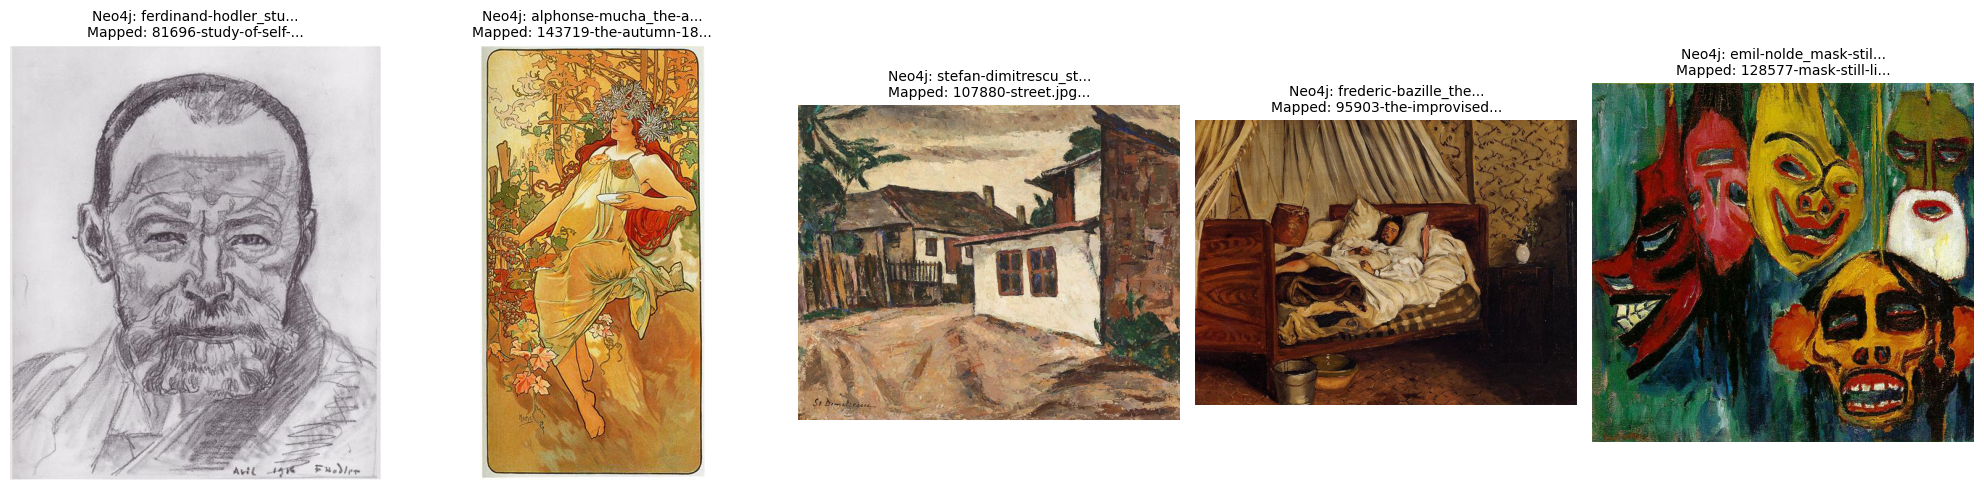

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

image_folder = "./worldkg_images"

print("=== 1. STRING MATCHING SANITY CHECK ===")
# A good mapping means the end of the URL (e.g., 'a-copse-evening-1918') 
# should be found inside the local file_name (e.g., '149638-a-copse-evening-1918.jpg')
def check_sane_mapping(row):
    if pd.isna(row['file_name']): return False
    
    # Extract just the painting name from the URL (ignoring folders and .jpg)
    url_base = str(row['clean_URL']).split('/')[-1].replace('.jpg', '').lower()
    # Extract the painting name from the local file
    file_base = str(row['file_name']).replace('.jpg', '').lower()
    
    # Check if one string is inside the other
    return (url_base in file_base) or (file_base in url_base)

merged_df['is_sane_match'] = merged_df.apply(check_sane_mapping, axis=1)
sane_match_count = merged_df['is_sane_match'].sum()
match_percentage = (sane_match_count / len(merged_df)) * 100

print(f"Total Rows: {len(merged_df)}")
print(f"Rows with logical text matches: {sane_match_count} ({match_percentage:.2f}%)")
if match_percentage > 95:
    print("✅ The mappings look highly accurate programmatically!")


print("\n=== 2. VISUAL RANDOM SAMPLE ===")
# Pick 5 random rows to display
sample_df = merged_df.sample(5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    local_path = os.path.join(image_folder, str(row['file_name']))
    
    try:
        img = Image.open(local_path)
        ax.imshow(img)
        
        # Display the Neo4j ID vs what we actually mapped it to
        title_text = f"Neo4j: {str(row['ImageName'])[:20]}...\nMapped: {str(row['file_name'])[:20]}..."
        ax.set_title(title_text, fontsize=10)
    except Exception as e:
        ax.set_title("Image Missing/Corrupt", fontsize=10)
        
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

print("=== 1. RANDOM SAMPLE OF 10 MAPPINGS ===")
# Print 10 random rows to manually verify the general mapping
sample_to_print = merged_df.sample(10)
for idx, row in sample_to_print.iterrows():
    # Extract just the painting name from the URL
    neo4j_expected = str(row['clean_URL']).split('/')[-1]
    local_mapped = str(row['file_name'])
    
    # The :<45 formatting just ensures the columns line up perfectly for easy reading
    print(f"URL Name: {neo4j_expected:<45} | Mapped File: {local_mapped}")


print("\n========================================================================\n")


print("=== 2. MANUAL CHECK OF 'FAILED' STRING MATCHES ===")
# Filter for the rows where our previous string matching check returned False
failed_matches = merged_df[merged_df['is_sane_match'] == False]

if len(failed_matches) > 0:
    print(f"Found {len(failed_matches)} mappings where the text didn't perfectly overlap.\nHere are the first 15 to check manually:\n")
    
    for idx, row in failed_matches.head(15).iterrows():
        neo4j_expected = str(row['clean_URL']).split('/')[-1]
        local_mapped = str(row['file_name'])
        
        print(f"URL Name: {neo4j_expected:<45} | Mapped File: {local_mapped}")
else:
    print("Zero failed string matches! Every single file shares its name with the URL.")

=== 1. RANDOM SAMPLE OF 10 MAPPINGS ===
URL Name: worcester-cathedral-river-severn.jpg          | Mapped File: 37826-worcester-cathedral-river-severn.jpg
URL Name: a-snare-of-vintage.jpg                        | Mapped File: 147267-a-snare-of-vintage.jpg
URL Name: my-mother-1893(1).jpg                         | Mapped File: 109283-my-mother-1893(1).jpg
URL Name: the-piazzetta-and-the-doge-s-palace.jpg       | Mapped File: 73244-the-piazzetta-and-the-doge-s-palace.jpg
URL Name: the-garden-wall.jpg                           | Mapped File: 97931-the-garden-wall.jpg
URL Name: twachtman-john-enchanted-pool.jpg             | Mapped File: 100364-twachtman-john-enchanted-pool.jpg
URL Name: virgin-and-child-with-saints.jpg              | Mapped File: 13899-virgin-and-child-with-saints.jpg
URL Name: centre-of-a-city-1925.jpg                     | Mapped File: 126414-centre-of-a-city-1925.jpg
URL Name: le-theatre-pirandello-1976.jpg                | Mapped File: 161302-le-theatre-pirandello-1976.

In [5]:
import numpy as np

# Load your newly created matrices
image_embeds = np.load('image_embeddings.npy')
graph_embeds = np.load('graph_embeddings.npy')

print("=== EMBEDDING DIMENSIONS ===")
print(f"Image Embeddings Shape: {image_embeds.shape}")
print(f"Graph Embeddings Shape: {graph_embeds.shape}")

print("\n=== QUICK CHECK ===")
if image_embeds.shape[0] == graph_embeds.shape[0]:
    print("✅ SUCCESS: The number of rows (paintings) perfectly match!")
else:
    print("❌ ERROR: The row counts are different. Alignment is broken.")

FileNotFoundError: [Errno 2] No such file or directory: 'image_embeddings.npy'

In [1]:
import numpy as np

# Load your new RN50x64 embeddings
#data = np.load('image_embeddings_rn5064.npy')
#data = np.load('graphsage_embeddings.npy')
data = np.load('image_embeddings_vitb32.npy')

print(f"Total images: {data.shape[0]}")
print(f"Max value: {np.max(data)}")
print(f"Min value: {np.min(data)}")

# Count how many vectors are completely empty (all zeros)
zero_vectors = np.sum(np.all(data == 0, axis=1))
print(f"\nNumber of completely empty/zero vectors: {zero_vectors}")
print(f"Percentage of broken data: {(zero_vectors / data.shape[0]) * 100:.2f}%")

Total images: 47224
Max value: 3.8125
Min value: -10.0078125

Number of completely empty/zero vectors: 0
Percentage of broken data: 0.00%


In [14]:
import os
import torch
from PIL import Image

# Grab just the very first image from your dataframe
test_row = merged_df.iloc[0]
local_path = os.path.join(image_folder, str(test_row['file_name']))

print(f"Attempting to load image at: {local_path}")

try:
    # 1. Open image
    image = Image.open(local_path).convert("RGB")
    print("✅ Image loaded successfully!")
    
    # 2. Preprocess
    image_input = preprocess(image).unsqueeze(0).to(device)
    print("✅ Image preprocessed successfully!")
    
    # 3. Extract (This is usually where RN50x64 crashes)
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        
    print(f"✅ Extraction successful! Vector shape: {image_features.shape}")

except Exception as e:
    print("\n❌ THE HIDDEN ERROR IS:")
    print(e)

Attempting to load image at: ./worldkg_images/149638-a-y-jackson-a-copse-evening-1918.jpg
✅ Image loaded successfully!
✅ Image preprocessed successfully!
✅ Extraction successful! Vector shape: torch.Size([1, 768])
